Data Import

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
df=pd.read_csv(r"/content/drive/MyDrive/Dataset_creditcard.csv")

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [42]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [43]:
#values in Class column
df['Class'] = df['Class'].map({0: 'No', 1: 'Yes'})

# Handling Duplicates


In [44]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,No
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,No
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,No
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,No
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,No


In [45]:
df.duplicated().sum()

np.int64(1081)

In [46]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [47]:
df.drop_duplicates(inplace=True)

In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
def outliers_iqr(pd_data):
    data=pd_data.copy()
    for i in data.columns:
        if pd.api.types.is_numeric_dtype(data[i]):
            q1=data[i].quantile(.25)
            q3=data[i].quantile(.75)
            iqr=q3-q1
            upper_limit=q3+1.5*iqr
            lower_limit=q1-1.5*iqr
            data[i]=data[i].clip(lower_limit, upper_limit)
    return data
df1=outliers_iqr(pd_data=df)

<function matplotlib.pyplot.show(close=None, block=None)>

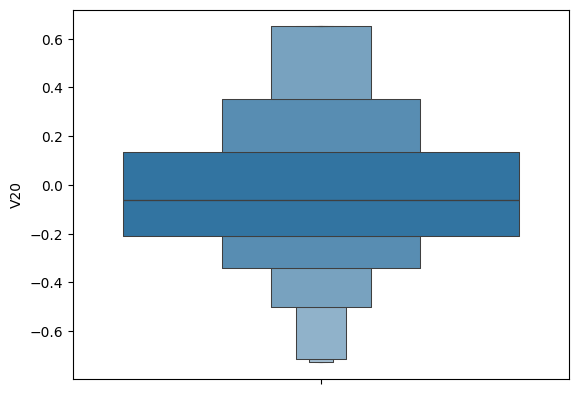

In [50]:
sns.boxenplot(df1["V20"])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

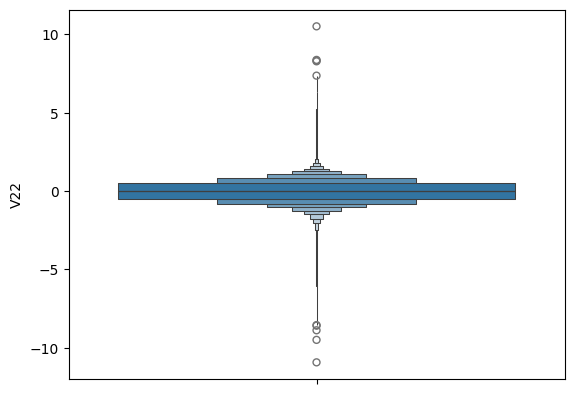

In [51]:
sns.boxenplot(df["V22"])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

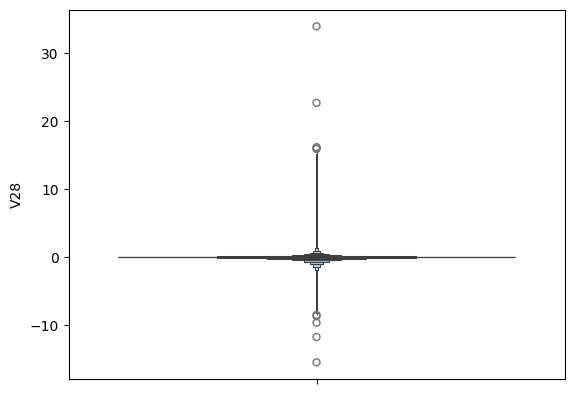

In [52]:
sns.boxenplot(df["V28"])
plt.show

In [53]:
df2=pd.get_dummies(df1, drop_first=True, dtype="int")

In [54]:
df2.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class_Yes'],
      dtype='object')

In [55]:
df2["Class_Yes"].value_counts()

,count
Class_Yes,
0,283253
1,473


## Model Building

In [56]:
y=df2["Class_Yes"]
x=df2.drop(columns=["Class_Yes"])

In [57]:
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=.3, random_state=1988)

In [58]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [59]:
log_model.score(x_train, y_train)

0.9993756545557078

In [60]:
pred_train=log_model.predict(x_train)
pred_test=log_model.predict(x_test)

In [61]:
pred_train

array([0, 0, 0, ..., 0, 0, 0])

In [62]:
pd.DataFrame({"actual":y_train, "predicted":pred_train}).head(10)

,actual,predicted
92516,0,0
102575,0,0
241324,0,0
115800,0,0
147713,0,0
122795,0,0
211605,0,0
132636,0,0
85511,0,0
31655,0,0


In [63]:
pd.DataFrame(metrics.confusion_matrix(y_train, pred_train),
             index=["act_0", "act_1"], columns=["pred_0", "pred_1"])

,pred_0,pred_1
act_0,198250,41
act_1,83,234


In [64]:
pd.DataFrame(metrics.confusion_matrix(y_test, pred_test),
             index=["act_0", "act_1"], columns=["pred_0", "pred_1"])

,pred_0,pred_1
act_0,84943,19
act_1,43,113


In [65]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

In [66]:
xgb_model = xgb.XGBClassifier(
    tree_method='hist',   # Changed from 'gpu_hist' to 'hist' for compatibility
    # predictor='gpu_predictor',# Uses GPU for prediction (commented out as tree_method is not gpu_hist)
    use_label_encoder=False,  # Avoids warnings
    eval_metric='logloss'     # Common evaluation metric
)

In [67]:
param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

In [68]:
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [69]:
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=2
)
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:42:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=2)

In [70]:
# Fit on training data
random_search.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:35:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=2)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:48:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=2)

In [71]:
# View results
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [72]:
# Get the best estimator from RandomizedSearchCV
best_xgb_model = random_search.best_estimator_

# Make predictions on the test set
y_pred_xgb = best_xgb_model.predict(x_test)
y_pred_proba_xgb = best_xgb_model.predict_proba(x_test)[:, 1] # Probability of the positive class

Model Evaluation

In [73]:
from sklearn.metrics import accuracy_score

# 1. Predict the labels using the best found estimator
y_pred = random_search.predict(x_test)

# 2. Compute and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy Score: {accuracy:.5f}")

Test Accuracy Score: 0.99946
Test Accuracy Score: 0.99946


In [74]:
from sklearn.metrics import precision_score

# Compute and print the precision score
precision = precision_score(y_test, y_pred)
print(f"Test Precision Score: {precision:.5f}")

Test Precision Score: 0.93651


In [75]:
from sklearn.metrics import recall_score

# Compute and print the recall score
recall = recall_score(y_test, y_pred)
print(f"Test Recall Score: {recall:.5f}")

Test Recall Score: 0.75641


In [76]:
from sklearn.metrics import f1_score

# Compute and print the F1-score
f1 = f1_score(y_test, y_pred)
print(f"Test F1-Score: {f1:.5f}")

Test F1-Score: 0.83688


In [77]:
from sklearn.metrics import roc_auc_score

# 1. Get predicted probabilities for all classes
# ([:, 1] extracts the probabilities for the positive class 'Yes' / 1)
y_pred_proba = random_search.predict_proba(x_test)[:, 1]

# 2. Compute and print the AUC-ROC score
auc_roc = roc_auc_score(y_test, y_pred_proba)
print(f"Test AUC-ROC Score: {auc_roc:.5f}")

Test AUC-ROC Score: 0.97890


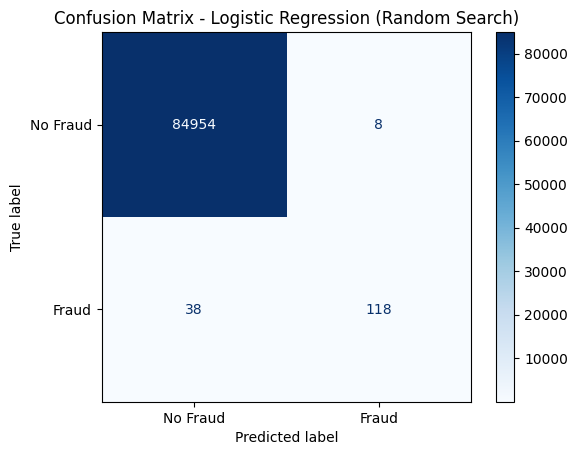

True Negatives (Legit caught): 84954
False Positives (False Alarms): 8
False Negatives (Missed Fraud): 38
True Positives (Fraud caught): 118


In [78]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Visualize the confusion matrix
# display_labels maps to your classes (0: 'No' / 1: 'Yes' for Fraud)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fraud', 'Fraud'])
disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title("Confusion Matrix - Logistic Regression (Random Search)")
plt.show()

# 3. Print out the raw counts for quick analysis
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (Legit caught): {tn}")
print(f"False Positives (False Alarms): {fp}")
print(f"False Negatives (Missed Fraud): {fn}")
print(f"True Positives (Fraud caught): {tp}")

In [79]:
import joblib

# Save the model
joblib.dump(random_search, "fraud_detection_model.pkl")

# Load the model back
loaded_model = joblib.load("fraud_detection_model.pkl")

# Verify it works
print(loaded_model)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           min_child_weight=None, missing=nan,
                